# EV Charging Network Monitor — eco-movement & Tesla

This notebook reads the dynamic status databases for **eco-movement** and
**Tesla** and visualizes the number of charging points actively in use
over time.

The collector stores status *transitions* (change-detection) between
periodic **SNAPSHOT** deliveries. Pure delta tracking drifts over time
because some transitions are missed between polls. We correct this by:

1. Using each **SNAPSHOT** as a ground-truth state reset.
2. Applying a **linear drift correction** between consecutive snapshots
   to eliminate the discontinuity that would otherwise appear.

## Download Current Data from Hetzner

The collectors run continuously on `178.104.101.146` (user `ev`).
Run the cell below to **sync the latest SQLite databases** to your
local `data/` folder.  After syncing you can work entirely offline.


In [2]:
import subprocess, sys
from pathlib import Path

SERVER = "ev@178.104.101.146"
SSH_KEY = Path.home() / ".ssh" / "id_ed25519"
REMOTE_DIR = "/home/ev/ev-monitor/data"
LOCAL_DIR = Path("data")

LOCAL_DIR.mkdir(exist_ok=True)

# Download all *.sqlite files (VACUUM copies, no WAL issues)
for provider in ("eco", "tesla"):
    for kind in ("static", "dynamic"):
        fname = f"{provider}_{kind}.sqlite"
        remote = f"{SERVER}:{REMOTE_DIR}/{fname}"
        local = LOCAL_DIR / fname
        print(f"Syncing {fname} … ", end="", flush=True)
        r = subprocess.run(
            ["scp", "-i", str(SSH_KEY), remote, str(local)],
            capture_output=True, text=True,
        )
        if r.returncode == 0:
            size_mb = local.stat().st_size / 1024 / 1024
            print(f"{size_mb:.1f} MB")
        else:
            print(f"FAILED: {r.stderr.strip()}")


Syncing eco_static.sqlite … 12.0 MB
Syncing eco_dynamic.sqlite … FAILED: scp: open local "data/eco_dynamic.sqlite": Broken pipe
Syncing tesla_static.sqlite … 0.0 MB
Syncing tesla_dynamic.sqlite … 1.7 MB


## Current State of the Charging Network

The **current state** is the result of replaying the last **SNAPSHOT**
(a full dump of every point's status) plus all subsequent **DELTA**
updates on top of it.  This gives the most recent known status of
every charging point in the system — entirely from local data.


In [3]:
import sqlite3
import pandas as pd
from pathlib import Path
from collections import Counter

PROVIDERS = {
    "eco_movement": {"slug": "eco",   "in_use": "charging", "label": "eco-movement"},
    "tesla":        {"slug": "tesla", "in_use": "occupied", "label": "Tesla"},
}


def current_state(slug: str) -> pd.DataFrame:
    """Return the last known status of every charging point.

    This is equivalent to the last SNAPSHOT + all subsequent DELTAs:
    for each point_id we take the row with the highest id (= most recent
    update), giving us the current status.
    """
    db = Path("data") / f"{slug}_dynamic.sqlite"
    with sqlite3.connect(db) as conn:
        return pd.read_sql_query(
            """
            SELECT h.point_id, h.status, h.collected_at_utc
            FROM point_status_history h
            INNER JOIN (
                SELECT point_id, MAX(id) AS max_id
                FROM point_status_history
                GROUP BY point_id
            ) latest ON h.id = latest.max_id
            """,
            conn,
        )


def static_info(slug: str) -> pd.DataFrame:
    """Load static metadata (coordinates, name, address, …)."""
    db = Path("data") / f"{slug}_static.sqlite"
    with sqlite3.connect(db) as conn:
        return pd.read_sql_query("SELECT * FROM charging_points", conn)


# ── Compute and display current state per provider ────────────────────
for name, cfg in PROVIDERS.items():
    slug = cfg["slug"]
    state = current_state(slug)
    static = static_info(slug)

    state["collected_at_utc"] = pd.to_datetime(state["collected_at_utc"])
    latest_update = state["collected_at_utc"].max()

    dist = Counter(state["status"])
    total = len(state)
    in_use = dist.get(cfg["in_use"], 0)

    print(f"\n{'═' * 55}")
    print(f"  {cfg['label']}  —  {total:,} points tracked")
    print(f"  Latest update: {latest_update:%Y-%m-%d %H:%M:%S} UTC")
    print(f"  Static metadata: {len(static):,} points")
    print(f"{'─' * 55}")
    for st, cnt in dist.most_common():
        bar = "█" * int(cnt / total * 40)
        print(f"  {st or '(none)':20s}  {cnt:>6,}  ({cnt/total*100:5.1f}%)  {bar}")
    print(f"{'═' * 55}")



═══════════════════════════════════════════════════════
  eco-movement  —  45,377 points tracked
  Latest update: 2026-03-30 17:25:19 UTC
  Static metadata: 45,139 points
───────────────────────────────────────────────────────
  available             36,887  ( 81.3%)  ████████████████████████████████
  charging               3,698  (  8.1%)  ███
  inoperative            2,985  (  6.6%)  ██
  outOfOrder               942  (  2.1%)  
  unknown                  752  (  1.7%)  
  blocked                   81  (  0.2%)  
  reserved                  32  (  0.1%)  
═══════════════════════════════════════════════════════

═══════════════════════════════════════════════════════
  Tesla  —  4,359 points tracked
  Latest update: 2026-03-30 18:33:16 UTC
  Static metadata: 3,808 points
───────────────────────────────────────────────────────
  available              2,101  ( 48.2%)  ███████████████████
  unknown                1,844  ( 42.3%)  ████████████████
  occupied                 368  (  8.4

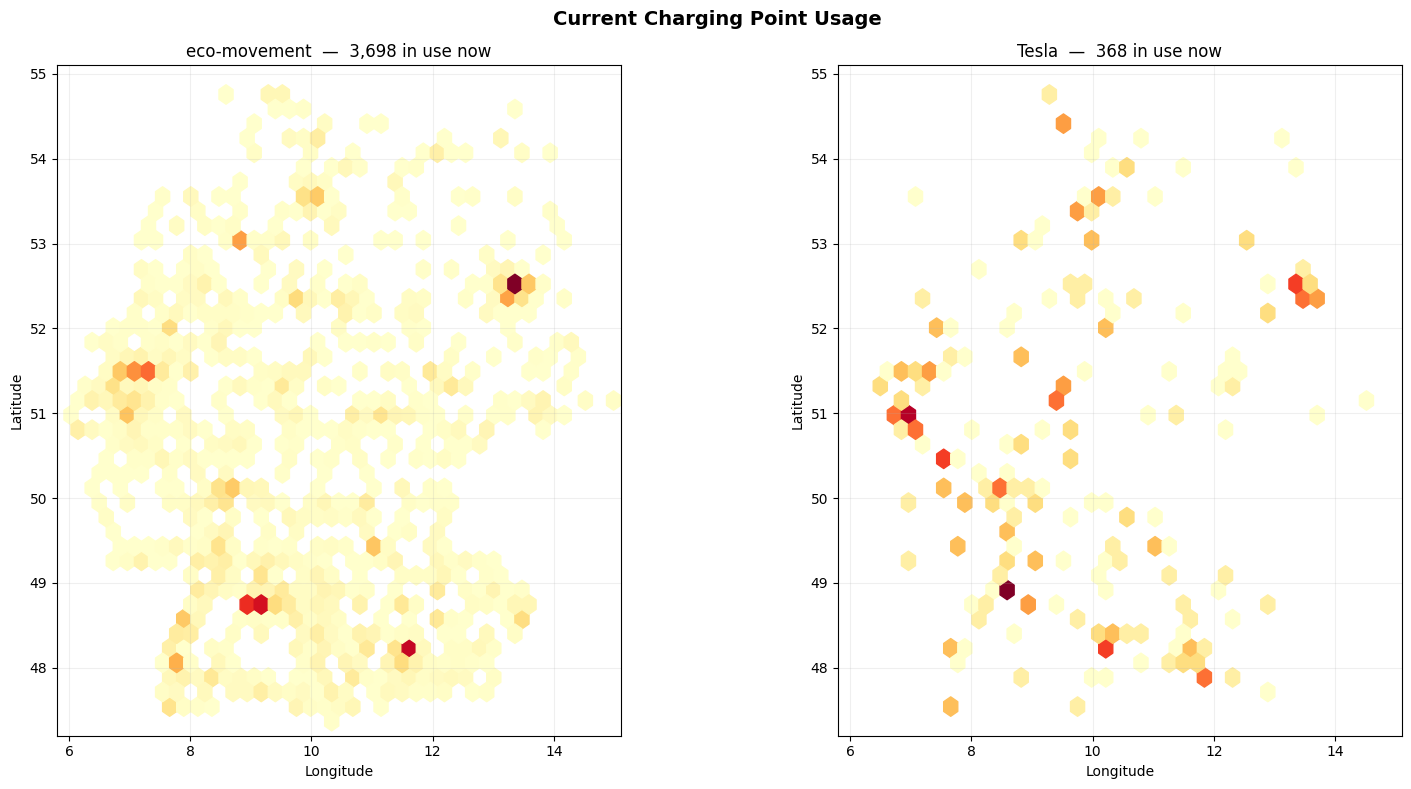

In [4]:
import matplotlib.pyplot as plt

# ── Map: currently in-use charging points ─────────────────────────────
LAT_MIN, LAT_MAX = 47.2, 55.1
LON_MIN, LON_MAX = 5.8, 15.1

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, (name, cfg) in zip(axes, PROVIDERS.items()):
    slug = cfg["slug"]
    state = current_state(slug)
    static = static_info(slug)

    # Merge to get coordinates for in-use points
    in_use_ids = set(state.loc[state["status"] == cfg["in_use"], "point_id"])
    geo = static[static["point_id"].isin(in_use_ids)].dropna(subset=["latitude", "longitude"])

    if not geo.empty:
        ax.hexbin(
            geo["longitude"], geo["latitude"],
            gridsize=40, cmap="YlOrRd", mincnt=1,
            extent=[LON_MIN, LON_MAX, LAT_MIN, LAT_MAX],
        )
    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_aspect(1.4)
    ax.set_title(f"{cfg['label']}  —  {len(in_use_ids):,} in use now", fontsize=12)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, alpha=0.2)

fig.suptitle("Current Charging Point Usage", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()


## Estimated Power Draw Over Time (MW)

Each charging point has a **rated power** in the static metadata
(`point_power_w` for eco-movement, `point_power_kw` for Tesla).
By replaying the dynamic history we know *which* points are in use at
each moment; summing their rated power gives an upper-bound estimate
of the instantaneous grid load from EV charging.

> **Note:** This is the *nameplate* power, not actual metered consumption.
> Real draw depends on vehicle SOC, cable limits, and load management.

In [5]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ── Provider config with power column names ───────────────────────────
POWER_CFG = {
    "eco": {
        "in_use": "charging",
        "power_col": "point_power_w",   # stored in watts
        "to_mw": 1e-6,                  # W → MW
        "color": "tab:blue",
        "label": "eco-movement",
    },
    "tesla": {
        "in_use": "occupied",
        "power_col": "point_power_kw",  # stored in kilowatts
        "to_mw": 1e-3,                  # kW → MW
        "color": "tab:red",
        "label": "Tesla",
    },
}


def replay_power_timeline(slug: str, in_use_status: str,
                          power_col: str, to_mw: float) -> pd.DataFrame:
    """Replay history and compute total MW drawn at each timestamp.

    For each timeline entry we know which point_ids are in-use.
    We look up their rated power from the static DB and sum to MW.
    """
    dyn_db = Path("data") / f"{slug}_dynamic.sqlite"
    sta_db = Path("data") / f"{slug}_static.sqlite"
    if not dyn_db.exists() or not sta_db.exists():
        return pd.DataFrame(columns=["time", "power_mw"])

    # Load per-point rated power from static DB
    with sqlite3.connect(sta_db) as conn:
        pdf = pd.read_sql_query(
            f"SELECT point_id, {power_col} FROM charging_points "
            f"WHERE {power_col} IS NOT NULL",
            conn,
        )
    power_map = dict(zip(pdf["point_id"], pdf[power_col] * to_mw))

    # Load dynamic history
    with sqlite3.connect(dyn_db) as conn:
        df = pd.read_sql_query(
            "SELECT h.point_id, h.status, h.collected_at_utc, "
            "       h.snapshot_id, s.delivery_type "
            "FROM point_status_history h "
            "JOIN snapshot_runs s ON h.snapshot_id = s.snapshot_id "
            "ORDER BY h.id",
            conn,
        )
    if df.empty:
        return pd.DataFrame(columns=["time", "power_mw"])

    df["collected_at_utc"] = pd.to_datetime(df["collected_at_utc"])
    snapshot_ids = set(df.loc[df["delivery_type"] == "SNAPSHOT", "snapshot_id"].unique())

    # Replay
    state: dict[str, str] = {}
    records: list[dict] = []

    for (sid, ts), group in df.groupby(
        ["snapshot_id", "collected_at_utc"], sort=False
    ):
        if sid in snapshot_ids:
            state = dict(zip(group["point_id"], group["status"]))
        else:
            for _, row in group.iterrows():
                state[row["point_id"]] = row["status"]

        total_mw = sum(
            power_map.get(pid, 0.0)
            for pid, s in state.items()
            if s == in_use_status
        )
        records.append({"time": ts, "power_mw": total_mw})

    result = pd.DataFrame(records).set_index("time").sort_index()
    return result


# ── Compute power timelines ──────────────────────────────────────────
power_series = {}
for slug, cfg in POWER_CFG.items():
    ts = replay_power_timeline(slug, cfg["in_use"], cfg["power_col"], cfg["to_mw"])
    if not ts.empty:
        power_series[slug] = ts
        print(f"{cfg['label']:15s}: {len(ts):>7,} samples, "
              f"peak = {ts['power_mw'].max():.1f} MW, "
              f"current = {ts['power_mw'].iloc[-1]:.1f} MW")
    else:
        print(f"{cfg['label']:15s}: no data")

# ── Combined total ────────────────────────────────────────────────────
if len(power_series) == 2:
    eco_ts = power_series["eco"].resample("1min").last().ffill()
    tesla_ts = power_series["tesla"].resample("1min").last().ffill()
    combined = eco_ts.add(tesla_ts, fill_value=0)
    print(f"\n{'Combined':15s}: peak = {combined['power_mw'].max():.1f} MW, "
          f"current = {combined['power_mw'].iloc[-1]:.1f} MW")

KeyboardInterrupt: 

In [ ]:
# ── Plot: Estimated Power Draw (MW) ──────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

# Top: stacked area
if len(power_series) == 2:
    eco_r = power_series["eco"].resample("1min").last().ffill()
    tesla_r = power_series["tesla"].resample("1min").last().ffill()
    # Align indices
    idx = eco_r.index.union(tesla_r.index)
    eco_v = eco_r.reindex(idx).ffill().fillna(0)["power_mw"]
    tesla_v = tesla_r.reindex(idx).ffill().fillna(0)["power_mw"]

    ax1.fill_between(idx, 0, eco_v, alpha=0.4,
                     color="tab:blue", label="eco-movement")
    ax1.fill_between(idx, eco_v, eco_v + tesla_v, alpha=0.4,
                     color="tab:red", label="Tesla")
    ax1.plot(idx, eco_v + tesla_v, linewidth=0.6, color="black",
             alpha=0.5, label="Total")
else:
    for slug, ts in power_series.items():
        cfg = POWER_CFG[slug]
        ax1.fill_between(ts.index, ts["power_mw"], alpha=0.4,
                         color=cfg["color"], label=cfg["label"])

ax1.set_ylabel("Power Draw (MW)")
ax1.set_title("Estimated Power Drawn from In-Use Chargers")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# Bottom: per-provider lines
for slug, ts in power_series.items():
    cfg = POWER_CFG[slug]
    ax2.plot(ts.index, ts["power_mw"], linewidth=0.7,
             color=cfg["color"], label=cfg["label"])

ax2.set_ylabel("MW")
ax2.set_xlabel("Time (UTC)")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3)
ax2.set_ylim(bottom=0)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.tight_layout()
plt.show()